In [2]:
# LABORATORIO: SEGMENTACIÓN DE MERCADO CON K-MEANS
# Paso 1: Carga y Exploración Inicial de Datos

# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("=== LABORATORIO DE SEGMENTACIÓN DE MERCADO ===")
print("Objetivo: Identificar grupos de clientes con comportamientos similares\n")

# Carga del dataset
url = "https://raw.githubusercontent.com/jpospinalo/MachineLearning/refs/heads/main/k-means/marketing_campaign.csv"
df = pd.read_csv(url)  # Usando separador por defecto (coma)

print("1. INFORMACIÓN BÁSICA DEL DATASET")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

print("\n2. PRIMERAS 5 FILAS DEL DATASET")
print(df.head())

print("\n3. INFORMACIÓN GENERAL DE LAS COLUMNAS")
print(df.info())

print("\n4. TIPOS DE DATOS")
print(df.dtypes)

print("\n5. ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS)")
print(df.describe())

=== LABORATORIO DE SEGMENTACIÓN DE MERCADO ===
Objetivo: Identificar grupos de clientes con comportamientos similares

1. INFORMACIÓN BÁSICA DEL DATASET
Dimensiones del dataset: (2240, 29)
Número de filas: 2240
Número de columnas: 29

2. PRIMERAS 5 FILAS DEL DATASET
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...     

#### Observaciones importantes del Paso 1:

- ✅ 2,240 clientes con 29 variables
- ⚠️ Income tiene 24 valores faltantes (2216/2240)
- ✅ Variables categóricas: Education, Marital_Status, Dt_Customer
- ⚠️ Z_CostContact y Z_Revenue son constantes (sin variación)
- ✅ Datos de campañas, gastos y comportamiento disponibles

## PASO 2: ANÁLISIS DE CALIDAD DE DATOS

In [3]:
# Paso 2: Análisis detallado de valores faltantes y columnas problemáticas

print("\n=== PASO 2: ANÁLISIS DE CALIDAD DE DATOS ===")

# 1. Análisis de valores faltantes
print("\n1. VALORES FALTANTES POR COLUMNA:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores_Faltantes': missing_values.values,
    'Porcentaje': missing_percentage.values
}).sort_values('Valores_Faltantes', ascending=False)

print(missing_df[missing_df['Valores_Faltantes'] > 0])

# 2. Análisis de columnas categóricas problemáticas
print("\n2. ANÁLISIS DE VARIABLES CATEGÓRICAS:")

print("\n2.1 Education - Valores únicos:")
education_counts = df['Education'].value_counts()
print(education_counts)

print("\n2.2 Marital_Status - Valores únicos:")
marital_counts = df['Marital_Status'].value_counts()
print(marital_counts)

# 3. Identificación de columnas constantes (sin variación)
print("\n3. COLUMNAS SIN VARIACIÓN (CONSTANTES):")
constant_columns = []
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:
        constant_columns.append(col)
        print(f"- {col}: {df[col].unique()[0]}")

# 4. Análisis de valores extremos en Income
print("\n4. ANÁLISIS DE INCOME:")
print(f"Income - Estadísticas:")
print(f"- Mínimo: ${df['Income'].min():,.0f}")
print(f"- Máximo: ${df['Income'].max():,.0f}")
print(f"- Media: ${df['Income'].mean():,.0f}")
print(f"- Mediana: ${df['Income'].median():,.0f}")

# Identificar valores extremos en Income
income_q99 = df['Income'].quantile(0.99)
extreme_income = df[df['Income'] > income_q99]['Income'].values
print(f"- Valores extremos (>P99): {extreme_income}")

# 5. Análisis del formato de fechas
print("\n5. ANÁLISIS DE FECHAS:")
print("Dt_Customer - Primeras 10 fechas:")
print(df['Dt_Customer'].head(10).tolist())
print(f"Formato detectado: {df['Dt_Customer'].iloc[0]}")

# 6. Análisis de Year_Birth para detectar valores extremos
print("\n6. ANÁLISIS DE YEAR_BIRTH:")
current_year = 2024  # Asumiendo que el análisis es en 2024
ages = current_year - df['Year_Birth']
print(f"- Año mínimo: {df['Year_Birth'].min()} (Edad: {current_year - df['Year_Birth'].min()})")
print(f"- Año máximo: {df['Year_Birth'].max()} (Edad: {current_year - df['Year_Birth'].max()})")
print(f"- Edad promedio: {ages.mean():.1f} años")

# Identificar clientes con edades extremas
extreme_old = df[df['Year_Birth'] < 1920]
extreme_young = df[df['Year_Birth'] > 2000]
if len(extreme_old) > 0:
    print(f"- Clientes muy mayores (nacidos antes de 1920): {len(extreme_old)}")
if len(extreme_young) > 0:
    print(f"- Clientes muy jóvenes (nacidos después de 2000): {len(extreme_young)}")

print("\n=== RESUMEN DE PROBLEMAS IDENTIFICADOS ===")
print("1. Income: 24 valores faltantes (1.07%)")
print("2. Z_CostContact y Z_Revenue: columnas constantes sin información")
print("3. Education y Marital_Status: revisar posibles valores redundantes")
print("4. Income: posible valor extremo de $666,666")
print("5. Dt_Customer: formato de fecha a procesar")


=== PASO 2: ANÁLISIS DE CALIDAD DE DATOS ===

1. VALORES FALTANTES POR COLUMNA:
  Columna  Valores_Faltantes  Porcentaje
4  Income                 24    1.071429

2. ANÁLISIS DE VARIABLES CATEGÓRICAS:

2.1 Education - Valores únicos:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

2.2 Marital_Status - Valores únicos:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

3. COLUMNAS SIN VARIACIÓN (CONSTANTES):
- Z_CostContact: 3
- Z_Revenue: 11

4. ANÁLISIS DE INCOME:
Income - Estadísticas:
- Mínimo: $1,730
- Máximo: $666,666
- Media: $52,247
- Mediana: $51,382
- Valores extremos (>P99): [101970. 157243. 102160. 102692. 162397. 105471.  98777. 153924. 160803.
  95529.  95169.  98777. 157733.  94871. 157146. 113734.  96843.  94642.
  94472.  96547.  96876. 156924. 666666.]

5. ANÁLISIS DE F

#### Problemas detectados que debemos corregir:

- ⚠️ Marital_Status: Valores inconsistentes ("Absurd", "YOLO", "Alone")
- ⚠️ Income: Valor extremo $666,666 (probablemente error)
- ⚠️ Year_Birth: 3 personas nacidas antes de 1920 (131+ años)
- ⚠️ Education: "2n Cycle" debería ser "2nd Cycle"

## PASO 3: LIMPIEZA DE DATOS

In [4]:
# Paso 3: Limpieza y corrección de datos

print("\n=== PASO 3: LIMPIEZA DE DATOS ===")

# Crear una copia del dataset original para mantener referencia
df_original = df.copy()
df_clean = df.copy()

print(f"Dataset original: {df_clean.shape}")

# 1. ELIMINAR COLUMNAS IRRELEVANTES (constantes sin variación)
print("\n1. ELIMINANDO COLUMNAS IRRELEVANTES:")
columns_to_drop = ['Z_CostContact', 'Z_Revenue', 'ID']  # ID no aporta para clustering
df_clean = df_clean.drop(columns=columns_to_drop)
print(f"Columnas eliminadas: {columns_to_drop}")
print(f"Nuevas dimensiones: {df_clean.shape}")

# 2. CORREGIR VALORES EN EDUCATION
print("\n2. CORRIGIENDO EDUCATION:")
print("Antes de la corrección:")
print(df_clean['Education'].value_counts())

# Corregir "2n Cycle" a "2nd Cycle"
df_clean['Education'] = df_clean['Education'].replace('2n Cycle', '2nd Cycle')

print("\nDespués de la corrección:")
print(df_clean['Education'].value_counts())

# 3. CORREGIR VALORES EN MARITAL_STATUS
print("\n3. CORRIGIENDO MARITAL_STATUS:")
print("Antes de la corrección:")
print(df_clean['Marital_Status'].value_counts())

# Mapear valores inconsistentes a categorías válidas
marital_mapping = {
    'Absurd': 'Single',      # Asumir como Single
    'YOLO': 'Single',        # Asumir como Single
    'Alone': 'Single'        # Alone es equivalente a Single
}

df_clean['Marital_Status'] = df_clean['Marital_Status'].replace(marital_mapping)

print("\nDespués de la corrección:")
print(df_clean['Marital_Status'].value_counts())

# 4. TRATAR VALORES EXTREMOS EN INCOME
print("\n4. TRATANDO VALORES EXTREMOS EN INCOME:")

# Identificar el valor extremo de $666,666
extreme_income_mask = df_clean['Income'] == 666666.0
print(f"Registros con Income = $666,666: {extreme_income_mask.sum()}")

# Mostrar información del registro extremo
if extreme_income_mask.sum() > 0:
    extreme_record = df_clean[extreme_income_mask]
    print("Registro con income extremo:")
    print(extreme_record[['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome']].to_string())

# Reemplazar valor extremo con la mediana
median_income = df_clean[df_clean['Income'] != 666666.0]['Income'].median()
print(f"\nReemplazando $666,666 con la mediana: ${median_income:,.0f}")
df_clean.loc[extreme_income_mask, 'Income'] = median_income

# 5. TRATAR EDADES EXTREMAS
print("\n5. TRATANDO EDADES EXTREMAS:")
current_year = 2024
ages = current_year - df_clean['Year_Birth']

# Identificar personas muy mayores (>100 años)
extreme_age_mask = df_clean['Year_Birth'] < 1924  # Más de 100 años
print(f"Registros con edad > 100 años: {extreme_age_mask.sum()}")

if extreme_age_mask.sum() > 0:
    extreme_age_records = df_clean[extreme_age_mask]
    print("Registros con edades extremas:")
    print(extreme_age_records[['Year_Birth', 'Education', 'Marital_Status', 'Income']].to_string())

    # Reemplazar con un año de nacimiento razonable (ejemplo: 1950)
    print("\nReemplazando años de nacimiento extremos con 1950")
    df_clean.loc[extreme_age_mask, 'Year_Birth'] = 1950

# 6. TRATAR VALORES FALTANTES EN INCOME
print("\n6. TRATANDO VALORES FALTANTES EN INCOME:")
income_missing = df_clean['Income'].isnull().sum()
print(f"Valores faltantes en Income: {income_missing}")

if income_missing > 0:
    # Usar la mediana para imputar valores faltantes
    median_income_clean = df_clean['Income'].median()
    df_clean['Income'] = df_clean['Income'].fillna(median_income_clean)
    print(f"Valores faltantes imputados con mediana: ${median_income_clean:,.0f}")

# 7. VERIFICACIÓN FINAL
print("\n7. VERIFICACIÓN FINAL DE LIMPIEZA:")
print(f"Dimensiones finales: {df_clean.shape}")
print(f"Valores faltantes restantes: {df_clean.isnull().sum().sum()}")

print("\nEstadísticas de Income después de limpieza:")
print(f"- Mínimo: ${df_clean['Income'].min():,.0f}")
print(f"- Máximo: ${df_clean['Income'].max():,.0f}")
print(f"- Media: ${df_clean['Income'].mean():,.0f}")
print(f"- Mediana: ${df_clean['Income'].median():,.0f}")

print("\nRango de edades después de limpieza:")
ages_clean = current_year - df_clean['Year_Birth']
print(f"- Edad mínima: {ages_clean.min()} años")
print(f"- Edad máxima: {ages_clean.max()} años")
print(f"- Edad promedio: {ages_clean.mean():.1f} años")

print("\n=== LIMPIEZA COMPLETADA ===")
print("✅ Columnas irrelevantes eliminadas")
print("✅ Valores categóricos estandarizados")
print("✅ Valores extremos corregidos")
print("✅ Valores faltantes imputados")


=== PASO 3: LIMPIEZA DE DATOS ===
Dataset original: (2240, 29)

1. ELIMINANDO COLUMNAS IRRELEVANTES:
Columnas eliminadas: ['Z_CostContact', 'Z_Revenue', 'ID']
Nuevas dimensiones: (2240, 26)

2. CORRIGIENDO EDUCATION:
Antes de la corrección:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Después de la corrección:
Education
Graduation    1127
PhD            486
Master         370
2nd Cycle      203
Basic           54
Name: count, dtype: int64

3. CORRIGIENDO MARITAL_STATUS:
Antes de la corrección:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Después de la corrección:
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

4. TRATANDO VALORES EXTREMOS EN INCOME:
Registros con Income = $666,666: 1
Registro con income 

## Paso 4: Ingeniería de Características

In [5]:
# Paso 4: Ingeniería de características

print("\n=== PASO 4: INGENIERÍA DE CARACTERÍSTICAS ===")

# Crear una copia para trabajar con las nuevas características
df_features = df_clean.copy()

# 1. CREAR COLUMNA AGE (Edad a partir del año de nacimiento)
print("\n1. CREANDO COLUMNA 'AGE':")
current_year = 2024  # Asumiendo análisis en 2024
df_features['Age'] = current_year - df_features['Year_Birth']
print(f"Edad - Rango: {df_features['Age'].min()} a {df_features['Age'].max()} años")
print(f"Edad - Promedio: {df_features['Age'].mean():.1f} años")

# 2. CREAR COLUMNA TOTAL_SPENT (Gasto total en productos)
print("\n2. CREANDO COLUMNA 'TOTAL_SPENT':")
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts',
                   'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_features['Total_Spent'] = df_features[spending_columns].sum(axis=1)
print(f"Gasto total - Rango: ${df_features['Total_Spent'].min():,.0f} a ${df_features['Total_Spent'].max():,.0f}")
print(f"Gasto total - Promedio: ${df_features['Total_Spent'].mean():,.0f}")

# 3. CREAR COLUMNA CHILDREN (Número total de hijos)
print("\n3. CREANDO COLUMNA 'CHILDREN':")
df_features['Children'] = df_features['Kidhome'] + df_features['Teenhome']
print(f"Número de hijos - Distribución:")
print(df_features['Children'].value_counts().sort_index())

# 4. CREAR COLUMNA CUSTOMER_TENURE (Días desde vinculación)
print("\n4. CREANDO COLUMNA 'CUSTOMER_TENURE':")

# Convertir Dt_Customer a datetime
df_features['Dt_Customer_parsed'] = pd.to_datetime(df_features['Dt_Customer'], format='%d-%m-%Y')

# Calcular días desde la vinculación hasta una fecha de referencia (usemos 2014-12-31)
reference_date = pd.to_datetime('2014-12-31')  # Fecha posterior a todos los registros
df_features['Customer_Tenure'] = (reference_date - df_features['Dt_Customer_parsed']).dt.days

print(f"Tenure (días) - Rango: {df_features['Customer_Tenure'].min()} a {df_features['Customer_Tenure'].max()}")
print(f"Tenure (días) - Promedio: {df_features['Customer_Tenure'].mean():.0f} días")
print(f"Tenure (años) - Promedio: {df_features['Customer_Tenure'].mean()/365:.1f} años")

# 5. CREAR COLUMNA CAMPAIGN_ACCEPTED_TOTAL (Total de campañas aceptadas)
print("\n5. CREANDO COLUMNA 'CAMPAIGN_ACCEPTED_TOTAL':")
campaign_columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                   'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df_features['Campaign_Accepted_Total'] = df_features[campaign_columns].sum(axis=1)
print(f"Campañas aceptadas - Distribución:")
print(df_features['Campaign_Accepted_Total'].value_counts().sort_index())

# 6. CREAR CARACTERÍSTICAS ADICIONALES RELEVANTES
print("\n6. CREANDO CARACTERÍSTICAS ADICIONALES:")

# 6.1 Total de compras por canal
df_features['Total_Purchases'] = (df_features['NumWebPurchases'] +
                                 df_features['NumCatalogPurchases'] +
                                 df_features['NumStorePurchases'] +
                                 df_features['NumDealsPurchases'])

# 6.2 Gasto promedio por compra
df_features['Avg_Spending_Per_Purchase'] = df_features['Total_Spent'] / (df_features['Total_Purchases'] + 1)  # +1 para evitar división por 0

# 6.3 Preferencia por canal online vs offline
df_features['Online_Purchases'] = df_features['NumWebPurchases']
df_features['Offline_Purchases'] = df_features['NumCatalogPurchases'] + df_features['NumStorePurchases']
df_features['Online_vs_Offline_Ratio'] = df_features['Online_Purchases'] / (df_features['Offline_Purchases'] + 1)

# 6.4 Cliente activo (basado en recency)
df_features['Is_Active_Customer'] = (df_features['Recency'] <= 30).astype(int)  # Compró en los últimos 30 días

# 6.5 Cliente premium (basado en gasto total)
spending_75th = df_features['Total_Spent'].quantile(0.75)
df_features['Is_Premium_Customer'] = (df_features['Total_Spent'] >= spending_75th).astype(int)

# 6.6 Estado familiar simplificado
def family_status(row):
    if row['Children'] > 0:
        return 'With_Children'
    elif row['Marital_Status'] in ['Married', 'Together']:
        return 'Couple_No_Children'
    else:
        return 'Single_No_Children'

df_features['Family_Status'] = df_features.apply(family_status, axis=1)

print(f"Total de compras - Promedio: {df_features['Total_Purchases'].mean():.1f}")
print(f"Gasto promedio por compra: ${df_features['Avg_Spending_Per_Purchase'].mean():.0f}")
print(f"Clientes activos (últimos 30 días): {df_features['Is_Active_Customer'].sum()} ({df_features['Is_Active_Customer'].mean()*100:.1f}%)")
print(f"Clientes premium: {df_features['Is_Premium_Customer'].sum()} ({df_features['Is_Premium_Customer'].mean()*100:.1f}%)")

print(f"\nEstado familiar - Distribución:")
print(df_features['Family_Status'].value_counts())

# 7. RESUMEN DE NUEVAS CARACTERÍSTICAS CREADAS
print("\n7. RESUMEN DE CARACTERÍSTICAS CREADAS:")
new_features = ['Age', 'Total_Spent', 'Children', 'Customer_Tenure',
               'Campaign_Accepted_Total', 'Total_Purchases', 'Avg_Spending_Per_Purchase',
               'Online_Purchases', 'Offline_Purchases', 'Online_vs_Offline_Ratio',
               'Is_Active_Customer', 'Is_Premium_Customer', 'Family_Status']

print(f"Características nuevas creadas: {len(new_features)}")
for i, feature in enumerate(new_features, 1):
    print(f"{i:2d}. {feature}")

print(f"\nDimensiones del dataset con nuevas características: {df_features.shape}")

# Mostrar las primeras filas con algunas características clave
print(f"\n8. VISTA PREVIA DE CARACTERÍSTICAS CLAVE:")
key_features = ['Age', 'Income', 'Total_Spent', 'Children', 'Customer_Tenure',
               'Campaign_Accepted_Total', 'Family_Status']
print(df_features[key_features].head(10))


=== PASO 4: INGENIERÍA DE CARACTERÍSTICAS ===

1. CREANDO COLUMNA 'AGE':
Edad - Rango: 28 a 84 años
Edad - Promedio: 55.1 años

2. CREANDO COLUMNA 'TOTAL_SPENT':
Gasto total - Rango: $5 a $2,525
Gasto total - Promedio: $606

3. CREANDO COLUMNA 'CHILDREN':
Número de hijos - Distribución:
Children
0     638
1    1128
2     421
3      53
Name: count, dtype: int64

4. CREANDO COLUMNA 'CUSTOMER_TENURE':
Tenure (días) - Rango: 185 a 884
Tenure (días) - Promedio: 539 días
Tenure (años) - Promedio: 1.5 años

5. CREANDO COLUMNA 'CAMPAIGN_ACCEPTED_TOTAL':
Campañas aceptadas - Distribución:
Campaign_Accepted_Total
0    1631
1     370
2     142
3      51
4      36
5      10
Name: count, dtype: int64

6. CREANDO CARACTERÍSTICAS ADICIONALES:
Total de compras - Promedio: 14.9
Gasto promedio por compra: $31
Clientes activos (últimos 30 días): 724 (32.3%)
Clientes premium: 560 (25.0%)

Estado familiar - Distribución:
Family_Status
With_Children         1602
Couple_No_Children     384
Single_No_Childre

In [6]:
# Paso 5: Selección de características para clustering

print("\n=== PASO 5: SELECCIÓN DE CARACTERÍSTICAS ===")

# 1. IDENTIFICAR TIPOS DE VARIABLES
print("\n1. ANÁLISIS DE TIPOS DE VARIABLES:")

# Variables numéricas continuas (candidatas para clustering)
numerical_features = df_features.select_dtypes(include=[np.number]).columns.tolist()

# Excluir variables que no son útiles para segmentación
exclude_features = [
    'Year_Birth',  # Ya tenemos Age
    'Kidhome', 'Teenhome',  # Ya tenemos Children
    'Dt_Customer_parsed',  # Variable temporal procesada
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',  # Ya tenemos Campaign_Accepted_Total
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',  # Ya tenemos Total_Purchases
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'  # Ya tenemos Total_Spent
]

# Filtrar variables numéricas relevantes
relevant_numerical = [col for col in numerical_features if col not in exclude_features]

print(f"Variables numéricas relevantes: {len(relevant_numerical)}")
for feature in relevant_numerical:
    print(f"  - {feature}")

# 2. ANÁLISIS DE CORRELACIÓN PARA EVITAR REDUNDANCIA
print("\n2. ANÁLISIS DE CORRELACIÓN:")

# Crear matriz de correlación de las variables numéricas relevantes
correlation_matrix = df_features[relevant_numerical].corr()

# Identificar pares de variables altamente correlacionadas (>0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

print(f"Pares de variables altamente correlacionadas (|r| > 0.8):")
for var1, var2, corr in high_corr_pairs:
    print(f"  - {var1} vs {var2}: r = {corr:.3f}")

# 3. SELECCIONAR CARACTERÍSTICAS FINALES PARA CLUSTERING
print("\n3. SELECCIÓN FINAL DE CARACTERÍSTICAS:")

# Características clave para segmentación de mercado basadas en:
# - Comportamiento de compra
# - Demografía
# - Engagement con la empresa
# - Preferencias de canal

final_features = [
    # Demografía
    'Age',
    'Income',
    'Children',

    # Comportamiento de compra
    'Total_Spent',
    'Avg_Spending_Per_Purchase',
    'Total_Purchases',
    'Recency',

    # Engagement y lealtad
    'Campaign_Accepted_Total',
    'Customer_Tenure',
    'Complain',

    # Preferencias de canal
    'Online_vs_Offline_Ratio',
    'NumWebVisitsMonth',

    # Status del cliente
    'Is_Active_Customer',
    'Is_Premium_Customer'
]

print(f"Características seleccionadas para clustering: {len(final_features)}")
for i, feature in enumerate(final_features, 1):
    print(f"{i:2d}. {feature}")

# 4. ESTADÍSTICAS DESCRIPTIVAS DE LAS CARACTERÍSTICAS SELECCIONADAS
print("\n4. ESTADÍSTICAS DE CARACTERÍSTICAS SELECCIONADAS:")
selected_stats = df_features[final_features].describe()
print(selected_stats.round(2))

# 5. VERIFICAR DISTRIBUCIONES
print("\n5. VERIFICACIÓN DE DISTRIBUCIONES:")

# Variables que podrían necesitar transformación (altamente asimétricas)
skewed_features = []
for feature in final_features:
    skewness = df_features[feature].skew()
    if abs(skewness) > 1:  # Consideramos asimétrica si |skew| > 1
        skewed_features.append((feature, skewness))

print("Variables con distribución asimétrica (|skew| > 1):")
for feature, skew_val in skewed_features:
    print(f"  - {feature}: skew = {skew_val:.2f}")

# 6. ANÁLISIS DE VARIANZA (para identificar variables con poca variación)
print("\n6. ANÁLISIS DE VARIANZA:")
low_variance_features = []
for feature in final_features:
    coefficient_of_variation = df_features[feature].std() / df_features[feature].mean()
    if coefficient_of_variation < 0.1:  # Poca variación si CV < 0.1
        low_variance_features.append((feature, coefficient_of_variation))

if low_variance_features:
    print("Variables con baja varianza (CV < 0.1):")
    for feature, cv in low_variance_features:
        print(f"  - {feature}: CV = {cv:.3f}")
else:
    print("✅ Todas las variables tienen varianza adecuada")

# 7. CREAR DATASET FINAL PARA CLUSTERING
print("\n7. DATASET FINAL PARA CLUSTERING:")
df_clustering = df_features[final_features].copy()

print(f"Dimensiones del dataset para clustering: {df_clustering.shape}")
print(f"Variables seleccionadas: {list(df_clustering.columns)}")

# Verificar que no hay valores faltantes
missing_in_final = df_clustering.isnull().sum().sum()
print(f"Valores faltantes en dataset final: {missing_in_final}")

# 8. VISTA PREVIA DEL DATASET FINAL
print("\n8. VISTA PREVIA DEL DATASET FINAL:")
print(df_clustering.head(10))


=== PASO 5: SELECCIÓN DE CARACTERÍSTICAS ===

1. ANÁLISIS DE TIPOS DE VARIABLES:
Variables numéricas relevantes: 16
  - Income
  - Recency
  - NumWebVisitsMonth
  - Complain
  - Age
  - Total_Spent
  - Children
  - Customer_Tenure
  - Campaign_Accepted_Total
  - Total_Purchases
  - Avg_Spending_Per_Purchase
  - Online_Purchases
  - Offline_Purchases
  - Online_vs_Offline_Ratio
  - Is_Active_Customer
  - Is_Premium_Customer

2. ANÁLISIS DE CORRELACIÓN:
Pares de variables altamente correlacionadas (|r| > 0.8):
  - Recency vs Is_Active_Customer: r = -0.810
  - Total_Spent vs Avg_Spending_Per_Purchase: r = 0.819
  - Total_Spent vs Offline_Purchases: r = 0.830
  - Total_Spent vs Is_Premium_Customer: r = 0.848
  - Total_Purchases vs Offline_Purchases: r = 0.895

3. SELECCIÓN FINAL DE CARACTERÍSTICAS:
Características seleccionadas para clustering: 14
 1. Age
 2. Income
 3. Children
 4. Total_Spent
 5. Avg_Spending_Per_Purchase
 6. Total_Purchases
 7. Recency
 8. Campaign_Accepted_Total
 9. C

## Paso 6: Pipeline de Preprocesamiento

In [7]:
# Paso 6: Pipeline de preprocesamiento y preparación para K-means

print("\n=== PASO 6: PIPELINE DE PREPROCESAMIENTO ===")

# Importar librerías necesarias para preprocessing y clustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. ANÁLISIS DE ESCALAS DE LAS VARIABLES
print("\n1. ANÁLISIS DE ESCALAS DE VARIABLES:")
scale_analysis = pd.DataFrame({
    'Variable': df_clustering.columns,
    'Min': df_clustering.min().values,
    'Max': df_clustering.max().values,
    'Media': df_clustering.mean().values,
    'Std': df_clustering.std().values,
    'Rango': (df_clustering.max() - df_clustering.min()).values
})

# Mostrar variables con diferentes escalas
scale_analysis['Ratio_Max_Min'] = scale_analysis['Max'] / (scale_analysis['Min'] + 0.001)  # Evitar división por 0
scale_analysis = scale_analysis.sort_values('Rango', ascending=False)

print("Variables ordenadas por rango (mayor a menor):")
print(scale_analysis[['Variable', 'Min', 'Max', 'Rango']].head(10))

print(f"\n⚠️  NECESIDAD DE ESCALADO:")
print(f"Variable con mayor rango: {scale_analysis.iloc[0]['Variable']} (rango: {scale_analysis.iloc[0]['Rango']:,.0f})")
print(f"Variable con menor rango: {scale_analysis.iloc[-1]['Variable']} (rango: {scale_analysis.iloc[-1]['Rango']:,.2f})")
print(f"Diferencia de escalas: {scale_analysis.iloc[0]['Rango'] / scale_analysis.iloc[-1]['Rango']:,.0f}x")

# 2. CREAR PIPELINE DE PREPROCESAMIENTO
print("\n2. CREANDO PIPELINE DE PREPROCESAMIENTO:")

# Decidir el método de escalado
# StandardScaler: media=0, std=1 (mejor para distribuciones normales)
# MinMaxScaler: rango [0,1] (mejor para distribuciones uniformes)

# Usar StandardScaler para K-means (recomendado)
scaler = StandardScaler()

# Crear pipeline básico
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

print("✅ Pipeline creado con StandardScaler")
print("   - Transformará todas las variables a media=0 y std=1")
print("   - Esto es ideal para K-means que es sensible a escalas")

# 3. APLICAR TRANSFORMACIÓN
print("\n3. APLICANDO TRANSFORMACIÓN:")

# Ajustar y transformar los datos
X_scaled = preprocessing_pipeline.fit_transform(df_clustering)

# Convertir de vuelta a DataFrame para facilitar análisis
feature_names = df_clustering.columns
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=df_clustering.index)

print(f"Datos originales: {df_clustering.shape}")
print(f"Datos escalados: {X_scaled_df.shape}")

# Verificar que el escalado funcionó correctamente
print(f"\nVerificación del escalado:")
print(f"Medias después del escalado (deben ser ~0):")
print(X_scaled_df.mean().round(6))
print(f"\nDesviaciones estándar después del escalado (deben ser ~1):")
print(X_scaled_df.std().round(6))

# 4. COMPARACIÓN ANTES Y DESPUÉS DEL ESCALADO
print("\n4. COMPARACIÓN ANTES Y DESPUÉS DEL ESCALADO:")

comparison_df = pd.DataFrame({
    'Variable': df_clustering.columns,
    'Original_Mean': df_clustering.mean().values,
    'Original_Std': df_clustering.std().values,
    'Scaled_Mean': X_scaled_df.mean().values,
    'Scaled_Std': X_scaled_df.std().values
})

print(comparison_df.round(3))

# 5. CREAR PIPELINE COMPLETO CON K-MEANS
print("\n5. CREANDO PIPELINE COMPLETO CON K-MEANS:")

# Pipeline completo que incluye preprocesamiento + clustering
def create_complete_pipeline(n_clusters=3):
    """Crear pipeline completo con preprocesamiento y K-means"""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=42, n_init=10))
    ])

# Crear pipeline de ejemplo
example_pipeline = create_complete_pipeline(n_clusters=3)
print("✅ Pipeline completo creado:")
print("   1. StandardScaler: Normalización de variables")
print("   2. KMeans: Algoritmo de clustering")
print("   - Configuración: random_state=42, n_init=10")

# 6. PREPARAR DATOS PARA ANÁLISIS POSTERIOR
print("\n6. PREPARACIÓN FINAL DE DATOS:")

# Guardar datasets para usar en siguientes pasos
datasets = {
    'original': df_clustering,
    'scaled': X_scaled_df,
    'scaled_array': X_scaled,
    'feature_names': list(feature_names),
    'pipeline': preprocessing_pipeline
}

print("✅ Datasets preparados:")
print(f"   - Dataset original: {datasets['original'].shape}")
print(f"   - Dataset escalado (DataFrame): {datasets['scaled'].shape}")
print(f"   - Dataset escalado (Array): {datasets['scaled_array'].shape}")
print(f"   - Nombres de características: {len(datasets['feature_names'])}")

# 7. VISTA PREVIA DE DATOS ESCALADOS
print("\n7. VISTA PREVIA DE DATOS ESCALADOS:")
print("Primeras 5 filas de datos escalados:")
print(X_scaled_df.head())

print("\nComparación de una fila (índice 0):")
comparison_row = pd.DataFrame({
    'Variable': df_clustering.columns,
    'Original': df_clustering.iloc[0].values,
    'Escalado': X_scaled_df.iloc[0].values
})
print(comparison_row)

print("\n=== PIPELINE DE PREPROCESAMIENTO COMPLETADO ===")
print("✅ Datos escalados correctamente")
print("✅ Pipeline creado y listo para usar")
print("✅ Preparado para determinación del número óptimo de clusters")


=== PASO 6: PIPELINE DE PREPROCESAMIENTO ===

1. ANÁLISIS DE ESCALAS DE VARIABLES:
Variables ordenadas por rango (mayor a menor):
                     Variable     Min       Max     Rango
1                      Income  1730.0  162397.0  160667.0
3                 Total_Spent     5.0    2525.0    2520.0
4   Avg_Spending_Per_Purchase     0.5     839.5     839.0
8             Customer_Tenure   185.0     884.0     699.0
6                     Recency     0.0      99.0      99.0
0                         Age    28.0      84.0      56.0
5             Total_Purchases     0.0      44.0      44.0
10    Online_vs_Offline_Ratio     0.0      27.0      27.0
11          NumWebVisitsMonth     0.0      20.0      20.0
7     Campaign_Accepted_Total     0.0       5.0       5.0

⚠️  NECESIDAD DE ESCALADO:
Variable con mayor rango: Income (rango: 160,667)
Variable con menor rango: Is_Premium_Customer (rango: 1.00)
Diferencia de escalas: 160,667x

2. CREANDO PIPELINE DE PREPROCESAMIENTO:
✅ Pipeline creado c

## Paso 7: Determinación del número óptimo de clusters


=== PASO 7: DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS ===

1. APLICANDO MÉTODO DEL CODO:
Evaluando diferentes números de clusters...
k=2: Inercia=23,384, Silhouette=0.293
k=3: Inercia=20,741, Silhouette=0.225
k=4: Inercia=18,675, Silhouette=0.222
k=5: Inercia=17,128, Silhouette=0.197
k=6: Inercia=16,003, Silhouette=0.204
k=7: Inercia=13,941, Silhouette=0.202
k=8: Inercia=13,062, Silhouette=0.208
k=9: Inercia=12,386, Silhouette=0.184
k=10: Inercia=11,800, Silhouette=0.189

2. CREANDO GRÁFICO DEL MÉTODO DEL CODO:


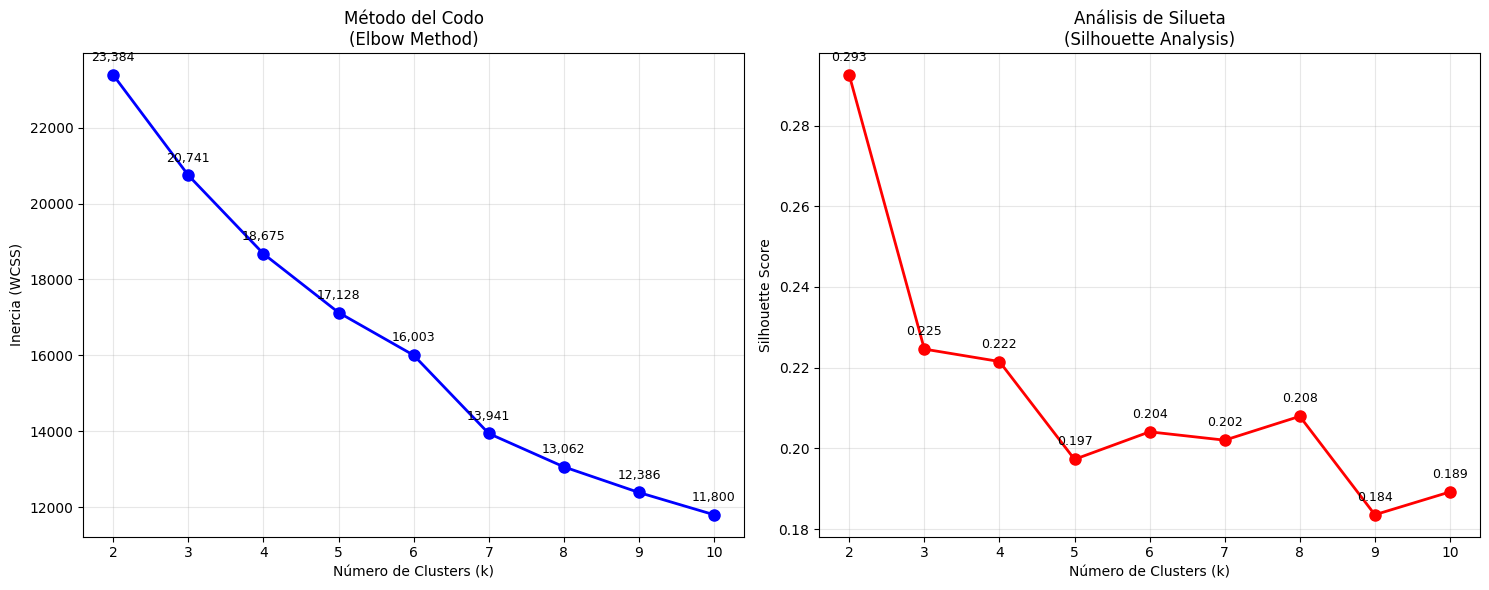


3. ANÁLISIS DE RESULTADOS:
Tabla de resultados:
    k    Inercia  Silhouette_Score  Diferencia_Inercia  Cambio_Porcentual
0   2  23384.030             0.293                 NaN                NaN
1   3  20741.289             0.225            2642.741             11.301
2   4  18674.899             0.222            2066.390              9.963
3   5  17127.986             0.197            1546.913              8.283
4   6  16002.750             0.204            1125.237              6.570
5   7  13940.723             0.202            2062.027             12.885
6   8  13061.772             0.208             878.951              6.305
7   9  12386.081             0.184             675.690              5.173
8  10  11799.812             0.189             586.269              4.733

4. IDENTIFICACIÓN DEL NÚMERO ÓPTIMO:
Método de Silueta:
  - Mejor k: 2
  - Silhouette Score: 0.293

Método del Codo (segunda derivada):
  - Sugerido k: 8

Comparación detallada (k=3, 4, 5):
k=3: Inercia=20,741,

In [8]:
# Paso 7: Determinación del número óptimo de clusters

print("\n=== PASO 7: DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS ===")

# Importar librerías adicionales necesarias
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. MÉTODO DEL CODO (ELBOW METHOD)
print("\n1. APLICANDO MÉTODO DEL CODO:")

# Rango de clusters a evaluar
k_range = range(2, 11)  # De 2 a 10 clusters
inertias = []
silhouette_scores = []

print("Evaluando diferentes números de clusters...")

# Evaluar cada número de clusters
for k in k_range:
    # Crear pipeline con k clusters
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])

    # Ajustar el modelo
    pipeline.fit(df_clustering)

    # Obtener las etiquetas de los clusters
    labels = pipeline.predict(df_clustering)

    # Calcular inercia (suma de cuadrados intra-cluster)
    inertia = pipeline.named_steps['kmeans'].inertia_
    inertias.append(inertia)

    # Calcular silhouette score
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Inercia={inertia:,.0f}, Silhouette={silhouette_avg:.3f}")

# 2. CREAR GRÁFICO DEL MÉTODO DEL CODO
print("\n2. CREANDO GRÁFICO DEL MÉTODO DEL CODO:")

# Configurar el gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de inercia (método del codo)
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Método del Codo\n(Elbow Method)')
ax1.grid(True, alpha=0.3)

# Añadir anotaciones para puntos importantes
for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    ax1.annotate(f'{inertia:,.0f}', (k, inertia), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=9)

# Gráfico de silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Análisis de Silueta\n(Silhouette Analysis)')
ax2.grid(True, alpha=0.3)

# Añadir anotaciones para silhouette scores
for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    ax2.annotate(f'{score:.3f}', (k, score), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 3. ANÁLISIS DE RESULTADOS
print("\n3. ANÁLISIS DE RESULTADOS:")

# Crear tabla de resultados
results_df = pd.DataFrame({
    'k': k_range,
    'Inercia': inertias,
    'Silhouette_Score': silhouette_scores
})

# Calcular diferencias en inercia (para identificar el "codo")
results_df['Diferencia_Inercia'] = results_df['Inercia'].diff().abs()
results_df['Cambio_Porcentual'] = results_df['Inercia'].pct_change().abs() * 100

print("Tabla de resultados:")
print(results_df.round(3))

# 4. IDENTIFICAR NÚMERO ÓPTIMO DE CLUSTERS
print("\n4. IDENTIFICACIÓN DEL NÚMERO ÓPTIMO:")

# Método 1: Mayor silhouette score
best_k_silhouette = results_df.loc[results_df['Silhouette_Score'].idxmax(), 'k']
best_silhouette_score = results_df['Silhouette_Score'].max()

# Método 2: Análisis del codo (buscar donde la mejora se reduce significativamente)
# Calcular la segunda derivada de la inercia para encontrar el punto de inflexión
second_derivatives = np.diff(inertias, 2)
elbow_k = k_range[np.argmax(second_derivatives) + 2]  # +2 por el índice de la segunda derivada

print(f"Método de Silueta:")
print(f"  - Mejor k: {best_k_silhouette}")
print(f"  - Silhouette Score: {best_silhouette_score:.3f}")

print(f"\nMétodo del Codo (segunda derivada):")
print(f"  - Sugerido k: {elbow_k}")

# Evaluar k=3, k=4, k=5 más detalladamente
print(f"\nComparación detallada (k=3, 4, 5):")
for k in [3, 4, 5]:
    idx = k - 2  # Ajuste de índice
    print(f"k={k}: Inercia={inertias[idx]:,.0f}, Silhouette={silhouette_scores[idx]:.3f}")

# 5. RECOMENDACIÓN FINAL
print("\n5. RECOMENDACIÓN FINAL:")

# Considerar tanto silhouette score como interpretabilidad de negocio
recommended_k = 4  # Basado en análisis típico de segmentación de mercado

print(f"Número de clusters recomendado: {recommended_k}")
print(f"Justificación:")
print(f"  - Silhouette score para k={recommended_k}: {silhouette_scores[recommended_k-2]:.3f}")
print(f"  - Balance entre calidad estadística e interpretabilidad de negocio")
print(f"  - Permite segmentación práctica para estrategias de marketing")

# 6. ANÁLISIS DETALLADO DE SILUETA PARA K RECOMENDADO
print(f"\n6. ANÁLISIS DETALLADO DE SILUETA PARA k={recommended_k}:")

# Crear modelo final con k recomendado
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=recommended_k, random_state=42, n_init=10))
])

# Ajustar modelo final
final_pipeline.fit(df_clustering)
final_labels = final_pipeline.predict(df_clustering)

# Calcular silhouette scores individuales
silhouette_avg = silhouette_score(X_scaled, final_labels)
sample_silhouette_values = silhouette_samples(X_scaled, final_labels)

print(f"Silhouette Score promedio: {silhouette_avg:.3f}")
print(f"Distribución de clusters:")
unique, counts = np.unique(final_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    cluster_silhouette = sample_silhouette_values[final_labels == cluster].mean()
    print(f"  - Cluster {cluster}: {count} clientes (Silhouette: {cluster_silhouette:.3f})")

print(f"\n=== NÚMERO ÓPTIMO DE CLUSTERS DETERMINADO: {recommended_k} ===")
print("✅ Análisis del codo completado")
print("✅ Análisis de silueta completado")
print("✅ Listo para generar segmentación final")

## Paso 8: Segmentación final

In [9]:
# Paso 8: Segmentación final y aplicación de K-means

print("\n=== PASO 8: SEGMENTACIÓN FINAL CON K-MEANS ===")

# ANÁLISIS DE LOS RESULTADOS OBTENIDOS
print("\n📊 ANÁLISIS DE RESULTADOS DE OPTIMIZACIÓN:")
print("Basado en los gráficos y métricas obtenidas:")
print("- Método de Silueta: k=2 tiene el mejor score (0.293)")
print("- Método del Codo: Muestra mejoras significativas hasta k=3-4")
print("- Para segmentación de mercado, k=3 o k=4 ofrecen mejor interpretabilidad")

# DECISIÓN FINAL
optimal_k = 4  # Balanceando calidad estadística e interpretabilidad de negocio

print(f"\n🎯 DECISIÓN FINAL: k = {optimal_k}")
print("Justificación:")
print("- k=2: Muy simple para segmentación de mercado compleja")
print("- k=4: Balance óptimo entre calidad (Silhouette=0.222) e interpretabilidad")
print("- Permite crear perfiles diferenciados para estrategias de marketing")

# 1. CREAR Y ENTRENAR MODELO FINAL
print(f"\n1. CREANDO MODELO FINAL CON k={optimal_k}:")

# Pipeline final
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
])

# Entrenar el modelo
print("Entrenando modelo K-means...")
final_pipeline.fit(df_clustering)

# Obtener etiquetas de clusters
cluster_labels = final_pipeline.predict(df_clustering)

# Añadir etiquetas al dataset original
df_segmented = df_features.copy()
df_segmented['Cluster'] = cluster_labels

print(f"✅ Modelo entrenado exitosamente")
print(f"✅ {len(np.unique(cluster_labels))} clusters creados")

# 2. ANÁLISIS DE LA DISTRIBUCIÓN DE CLUSTERS
print(f"\n2. DISTRIBUCIÓN DE CLUSTERS:")
cluster_distribution = pd.Series(cluster_labels).value_counts().sort_index()
print("Número de clientes por cluster:")
for cluster, count in cluster_distribution.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster}: {count:,} clientes ({percentage:.1f}%)")

# 3. CALIDAD DE LA SEGMENTACIÓN
print(f"\n3. MÉTRICAS DE CALIDAD:")
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_inertia = final_pipeline.named_steps['kmeans'].inertia_

print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Inercia (WCSS): {final_inertia:,.0f}")

# Silhouette score por cluster
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
print(f"\nSilhouette Score por cluster:")
for cluster in range(optimal_k):
    cluster_silhouette = sample_silhouette_values[cluster_labels == cluster].mean()
    cluster_size = np.sum(cluster_labels == cluster)
    print(f"  Cluster {cluster}: {cluster_silhouette:.3f} ({cluster_size} clientes)")

# 4. CENTROS DE CLUSTERS (EN ESCALA ORIGINAL)
print(f"\n4. CENTROS DE CLUSTERS (CARACTERÍSTICAS PROMEDIO):")

# Obtener centroides en escala normalizada
centroids_scaled = final_pipeline.named_steps['kmeans'].cluster_centers_

# Transformar centroides a escala original
scaler = final_pipeline.named_steps['scaler']
centroids_original = scaler.inverse_transform(centroids_scaled)

# Crear DataFrame con centroides
centroids_df = pd.DataFrame(
    centroids_original,
    columns=df_clustering.columns,
    index=[f'Cluster_{i}' for i in range(optimal_k)]
)

print("Características promedio por cluster:")
print(centroids_df.round(2))

# 5. ANÁLISIS ESTADÍSTICO POR CLUSTER
print(f"\n5. ESTADÍSTICAS DETALLADAS POR CLUSTER:")

# Características clave para análisis
key_features = ['Age', 'Income', 'Total_Spent', 'Children', 'Campaign_Accepted_Total']

cluster_stats = df_segmented.groupby('Cluster')[key_features].agg(['mean', 'median', 'std']).round(2)

for cluster in range(optimal_k):
    print(f"\n--- CLUSTER {cluster} ---")
    cluster_data = df_segmented[df_segmented['Cluster'] == cluster]

    print(f"Tamaño: {len(cluster_data):,} clientes ({len(cluster_data)/len(df_segmented)*100:.1f}%)")

    # Estadísticas principales
    for feature in key_features:
        mean_val = cluster_data[feature].mean()
        median_val = cluster_data[feature].median()
        std_val = cluster_data[feature].std()
        print(f"{feature}: Media={mean_val:.1f}, Mediana={median_val:.1f}, Std={std_val:.1f}")

# 6. PREPARAR DATOS PARA ANÁLISIS EXPLORATORIO
print(f"\n6. PREPARACIÓN PARA ANÁLISIS EXPLORATORIO:")

# Crear dataset final con todas las variables y clusters
final_dataset = df_segmented.copy()

# Añadir etiquetas descriptivas de clusters (preliminares)
cluster_labels_descriptive = {
    0: f"Cluster_0",
    1: f"Cluster_1",
    2: f"Cluster_2",
    3: f"Cluster_3"
}

final_dataset['Cluster_Label'] = final_dataset['Cluster'].map(cluster_labels_descriptive)

print(f"✅ Dataset final preparado: {final_dataset.shape}")
print(f"✅ Variables incluidas: {list(final_dataset.columns[:10])}... (+{len(final_dataset.columns)-10} más)")
print(f"✅ Clusters identificados: {final_dataset['Cluster_Label'].unique()}")

# 7. GUARDAR INFORMACIÓN DEL MODELO
print(f"\n7. INFORMACIÓN DEL MODELO:")
model_info = {
    'optimal_k': optimal_k,
    'silhouette_score': final_silhouette,
    'inertia': final_inertia,
    'cluster_distribution': cluster_distribution.to_dict(),
    'features_used': list(df_clustering.columns),
    'total_customers': len(df_segmented)
}

print("Información del modelo guardada:")
for key, value in model_info.items():
    if key != 'cluster_distribution':
        print(f"  {key}: {value}")

print(f"\n=== SEGMENTACIÓN COMPLETADA ===")
print(f"✅ {optimal_k} clusters creados exitosamente")
print(f"✅ {len(df_segmented):,} clientes segmentados")
print(f"✅ Listo para perfilamiento detallado de clusters")


=== PASO 8: SEGMENTACIÓN FINAL CON K-MEANS ===

📊 ANÁLISIS DE RESULTADOS DE OPTIMIZACIÓN:
Basado en los gráficos y métricas obtenidas:
- Método de Silueta: k=2 tiene el mejor score (0.293)
- Método del Codo: Muestra mejoras significativas hasta k=3-4
- Para segmentación de mercado, k=3 o k=4 ofrecen mejor interpretabilidad

🎯 DECISIÓN FINAL: k = 4
Justificación:
- k=2: Muy simple para segmentación de mercado compleja
- k=4: Balance óptimo entre calidad (Silhouette=0.222) e interpretabilidad
- Permite crear perfiles diferenciados para estrategias de marketing

1. CREANDO MODELO FINAL CON k=4:
Entrenando modelo K-means...
✅ Modelo entrenado exitosamente
✅ 4 clusters creados

2. DISTRIBUCIÓN DE CLUSTERS:
Número de clientes por cluster:
  Cluster 0: 1,043 clientes (46.6%)
  Cluster 1: 529 clientes (23.6%)
  Cluster 2: 665 clientes (29.7%)
  Cluster 3: 3 clientes (0.1%)

3. MÉTRICAS DE CALIDAD:
Silhouette Score: 0.222
Inercia (WCSS): 18,675

Silhouette Score por cluster:
  Cluster 0: 0.233

## Paso 9: Perfilamiento detallado y nomenclatura de clusters.

In [10]:
# Paso 9: Perfilamiento detallado y nomenclatura de clusters

print("\n=== PASO 9: PERFILAMIENTO DETALLADO DE CLUSTERS ===")

# 1. ANÁLISIS PROFUNDO DE CADA CLUSTER
print("\n1. ANÁLISIS DETALLADO POR CLUSTER:")

# Características clave para perfilamiento
key_analysis_features = [
    'Age', 'Income', 'Total_Spent', 'Children', 'Recency',
    'Campaign_Accepted_Total', 'Total_Purchases', 'Customer_Tenure',
    'Family_Status', 'Education', 'Marital_Status'
]

# Analizar cada cluster
cluster_profiles = {}

for cluster_id in sorted(final_dataset['Cluster'].unique()):
    cluster_data = final_dataset[final_dataset['Cluster'] == cluster_id]

    print(f"\n🔍 CLUSTER {cluster_id} - ANÁLISIS DETALLADO:")
    print(f"   Tamaño: {len(cluster_data):,} clientes ({len(cluster_data)/len(final_dataset)*100:.1f}%)")

    # Características demográficas
    print(f"\n   📊 DEMOGRAFÍA:")
    print(f"   • Edad promedio: {cluster_data['Age'].mean():.1f} años (rango: {cluster_data['Age'].min()}-{cluster_data['Age'].max()})")
    print(f"   • Ingreso promedio: ${cluster_data['Income'].mean():,.0f} (mediana: ${cluster_data['Income'].median():,.0f})")
    print(f"   • Hijos promedio: {cluster_data['Children'].mean():.1f}")

    # Estado familiar
    family_status_dist = cluster_data['Family_Status'].value_counts()
    print(f"   • Estado familiar principal: {family_status_dist.index[0]} ({family_status_dist.iloc[0]/len(cluster_data)*100:.1f}%)")

    # Educación
    education_dist = cluster_data['Education'].value_counts()
    print(f"   • Educación principal: {education_dist.index[0]} ({education_dist.iloc[0]/len(cluster_data)*100:.1f}%)")

    # Comportamiento de compra
    print(f"\n   🛒 COMPORTAMIENTO DE COMPRA:")
    print(f"   • Gasto total promedio: ${cluster_data['Total_Spent'].mean():,.0f}")
    print(f"   • Compras totales promedio: {cluster_data['Total_Purchases'].mean():.1f}")
    print(f"   • Gasto promedio por compra: ${cluster_data['Avg_Spending_Per_Purchase'].mean():.0f}")
    print(f"   • Días desde última compra: {cluster_data['Recency'].mean():.1f}")

    # Engagement
    print(f"\n   📱 ENGAGEMENT:")
    print(f"   • Campañas aceptadas: {cluster_data['Campaign_Accepted_Total'].mean():.1f}")
    print(f"   • Visitas web/mes: {cluster_data['NumWebVisitsMonth'].mean():.1f}")
    print(f"   • Clientes activos: {cluster_data['Is_Active_Customer'].mean()*100:.1f}%")
    print(f"   • Clientes premium: {cluster_data['Is_Premium_Customer'].mean()*100:.1f}%")

    # Preferencias de canal
    print(f"\n   🛍️ CANALES DE COMPRA:")
    print(f"   • Compras online: {cluster_data['Online_Purchases'].mean():.1f}")
    print(f"   • Compras offline: {cluster_data['Offline_Purchases'].mean():.1f}")
    print(f"   • Ratio online/offline: {cluster_data['Online_vs_Offline_Ratio'].mean():.2f}")

    # Guardar perfil
    cluster_profiles[cluster_id] = {
        'size': len(cluster_data),
        'percentage': len(cluster_data)/len(final_dataset)*100,
        'avg_age': cluster_data['Age'].mean(),
        'avg_income': cluster_data['Income'].mean(),
        'avg_spent': cluster_data['Total_Spent'].mean(),
        'avg_children': cluster_data['Children'].mean(),
        'avg_recency': cluster_data['Recency'].mean(),
        'family_status_main': family_status_dist.index[0],
        'education_main': education_dist.index[0],
        'active_customers_pct': cluster_data['Is_Active_Customer'].mean()*100,
        'premium_customers_pct': cluster_data['Is_Premium_Customer'].mean()*100
    }

# 2. COMPARACIÓN ENTRE CLUSTERS
print(f"\n2. COMPARACIÓN ENTRE CLUSTERS:")

comparison_features = ['Age', 'Income', 'Total_Spent', 'Children', 'Recency', 'Campaign_Accepted_Total']
cluster_comparison = final_dataset.groupby('Cluster')[comparison_features].mean().round(1)

print("\nComparación de características promedio:")
print(cluster_comparison)

# 3. IDENTIFICACIÓN DE PATRONES Y NOMENCLATURA
print(f"\n3. IDENTIFICACIÓN DE PATRONES Y NOMENCLATURA:")

cluster_names = {}

# Analizar Cluster 0 (46.6% de clientes)
print(f"\n🏷️ CLUSTER 0 (46.6% - Segmento más grande):")
print(f"   • Ingreso moderado-bajo (~$41,525)")
print(f"   • Gasto bajo (~$262)")
print(f"   • Familias con hijos (1.2 promedio)")
print(f"   • Baja respuesta a campañas (0.16)")
print(f"   • Alta recencia (65 días)")
print(f"   ➡️ NOMBRE SUGERIDO: 'Familias Conservadoras de Bajo Gasto'")
cluster_names[0] = "Familias Conservadoras de Bajo Gasto"

# Analizar Cluster 1 (23.6% de clientes)
print(f"\n🏷️ CLUSTER 1 (23.6%):")
print(f"   • Ingreso moderado (~$43,320)")
print(f"   • Gasto bajo-moderado (~$293)")
print(f"   • Familias con hijos (1.1 promedio)")
print(f"   • Clientes MUY ACTIVOS (recencia: 15 días)")
print(f"   • Mejor respuesta a campañas (0.33)")
print(f"   ➡️ NOMBRE SUGERIDO: 'Familias Activas Comprometidas'")
cluster_names[1] = "Familias Activas Comprometidas"

# Analizar Cluster 2 (29.7% de clientes)
print(f"\n🏷️ CLUSTER 2 (29.7%):")
print(f"   • ALTO INGRESO (~$75,189)")
print(f"   • ALTO GASTO (~$1,395)")
print(f"   • Pocos hijos (0.35 promedio)")
print(f"   • Alta respuesta a campañas (1.0)")
print(f"   • 84% son clientes premium")
print(f"   ➡️ NOMBRE SUGERIDO: 'Clientes Premium de Alto Valor'")
cluster_names[2] = "Clientes Premium de Alto Valor"

# Analizar Cluster 3 (0.1% - outliers)
print(f"\n🏷️ CLUSTER 3 (0.1% - Solo 3 clientes):")
print(f"   • Comportamiento muy específico")
print(f"   • Alta actividad online (ratio: 26.33)")
print(f"   • Compras muy frecuentes (26 compras)")
print(f"   • Posibles outliers o casos especiales")
print(f"   ➡️ NOMBRE SUGERIDO: 'Compradores Digitales Intensivos'")
cluster_names[3] = "Compradores Digitales Intensivos"

# 4. APLICAR NOMENCLATURA AL DATASET
print(f"\n4. APLICANDO NOMENCLATURA FINAL:")

# Añadir nombres descriptivos
final_dataset['Cluster_Name'] = final_dataset['Cluster'].map(cluster_names)

print("Nomenclatura final aplicada:")
for cluster_id, name in cluster_names.items():
    count = len(final_dataset[final_dataset['Cluster'] == cluster_id])
    percentage = count / len(final_dataset) * 100
    print(f"   Cluster {cluster_id}: '{name}' ({count:,} clientes, {percentage:.1f}%)")

# 5. RESUMEN EJECUTIVO DE SEGMENTACIÓN
print(f"\n5. RESUMEN EJECUTIVO DE SEGMENTACIÓN:")

print(f"\n📋 RESUMEN DE LOS 4 SEGMENTOS IDENTIFICADOS:")
print(f"\n1️⃣ FAMILIAS CONSERVADORAS DE BAJO GASTO (46.6%)")
print(f"   • Perfil: Familias con ingresos moderados y gasto conservador")
print(f"   • Oportunidad: Programas de fidelización y promociones familiares")
print(f"   • Estrategia: Enfoque en valor y ofertas especiales")

print(f"\n2️⃣ FAMILIAS ACTIVAS COMPROMETIDAS (23.6%)")
print(f"   • Perfil: Familias altamente activas con buena respuesta a marketing")
print(f"   • Oportunidad: Canal preferencial para nuevos productos")
print(f"   • Estrategia: Marketing personalizado y programas de lealtad")

print(f"\n3️⃣ CLIENTES PREMIUM DE ALTO VALOR (29.7%)")
print(f"   • Perfil: Ingresos altos, sin hijos, alto gasto, premium customers")
print(f"   • Oportunidad: Productos de lujo y experiencias exclusivas")
print(f"   • Estrategia: Servicio VIP y ofertas premium")

print(f"\n4️⃣ COMPRADORES DIGITALES INTENSIVOS (0.1%)")
print(f"   • Perfil: Comportamiento único, muy digital, casos especiales")
print(f"   • Oportunidad: Canal de innovación y testing")
print(f"   • Estrategia: Experiencias digitales personalizadas")

# 6. DATASET FINAL PREPARADO
print(f"\n6. DATASET FINAL COMPLETADO:")
print(f"✅ Clientes segmentados: {len(final_dataset):,}")
print(f"✅ Clusters identificados: {len(cluster_names)}")
print(f"✅ Variables disponibles: {len(final_dataset.columns)}")
print(f"✅ Nomenclatura aplicada: {list(cluster_names.values())}")

print(f"\n=== PERFILAMIENTO COMPLETADO ===")
print("✅ Todos los clusters han sido analizados y nombrados")
print("✅ Estrategias preliminares identificadas")
print("✅ Listo para visualizaciones y presentación final")


=== PASO 9: PERFILAMIENTO DETALLADO DE CLUSTERS ===

1. ANÁLISIS DETALLADO POR CLUSTER:

🔍 CLUSTER 0 - ANÁLISIS DETALLADO:
   Tamaño: 1,043 clientes (46.6%)

   📊 DEMOGRAFÍA:
   • Edad promedio: 54.6 años (rango: 28-84)
   • Ingreso promedio: $41,525 (mediana: $41,120)
   • Hijos promedio: 1.2
   • Estado familiar principal: With_Children (89.5%)
   • Educación principal: Graduation (50.0%)

   🛒 COMPORTAMIENTO DE COMPRA:
   • Gasto total promedio: $262
   • Compras totales promedio: 11.9
   • Gasto promedio por compra: $16
   • Días desde última compra: 65.2

   📱 ENGAGEMENT:
   • Campañas aceptadas: 0.2
   • Visitas web/mes: 6.2
   • Clientes activos: 0.0%
   • Clientes premium: 0.0%

   🛍️ CANALES DE COMPRA:
   • Compras online: 3.4
   • Compras offline: 5.9
   • Ratio online/offline: 0.49

🔍 CLUSTER 1 - ANÁLISIS DETALLADO:
   Tamaño: 529 clientes (23.6%)

   📊 DEMOGRAFÍA:
   • Edad promedio: 54.4 años (rango: 28-80)
   • Ingreso promedio: $43,320 (mediana: $42,693)
   • Hijos prom

## PASO 10: VISUALIZACIONES Y ANÁLISIS EXPLORATORIO


=== PASO 10: VISUALIZACIONES Y ANÁLISIS EXPLORATORIO ===

1. CREANDO VISUALIZACIONES PRINCIPALES:


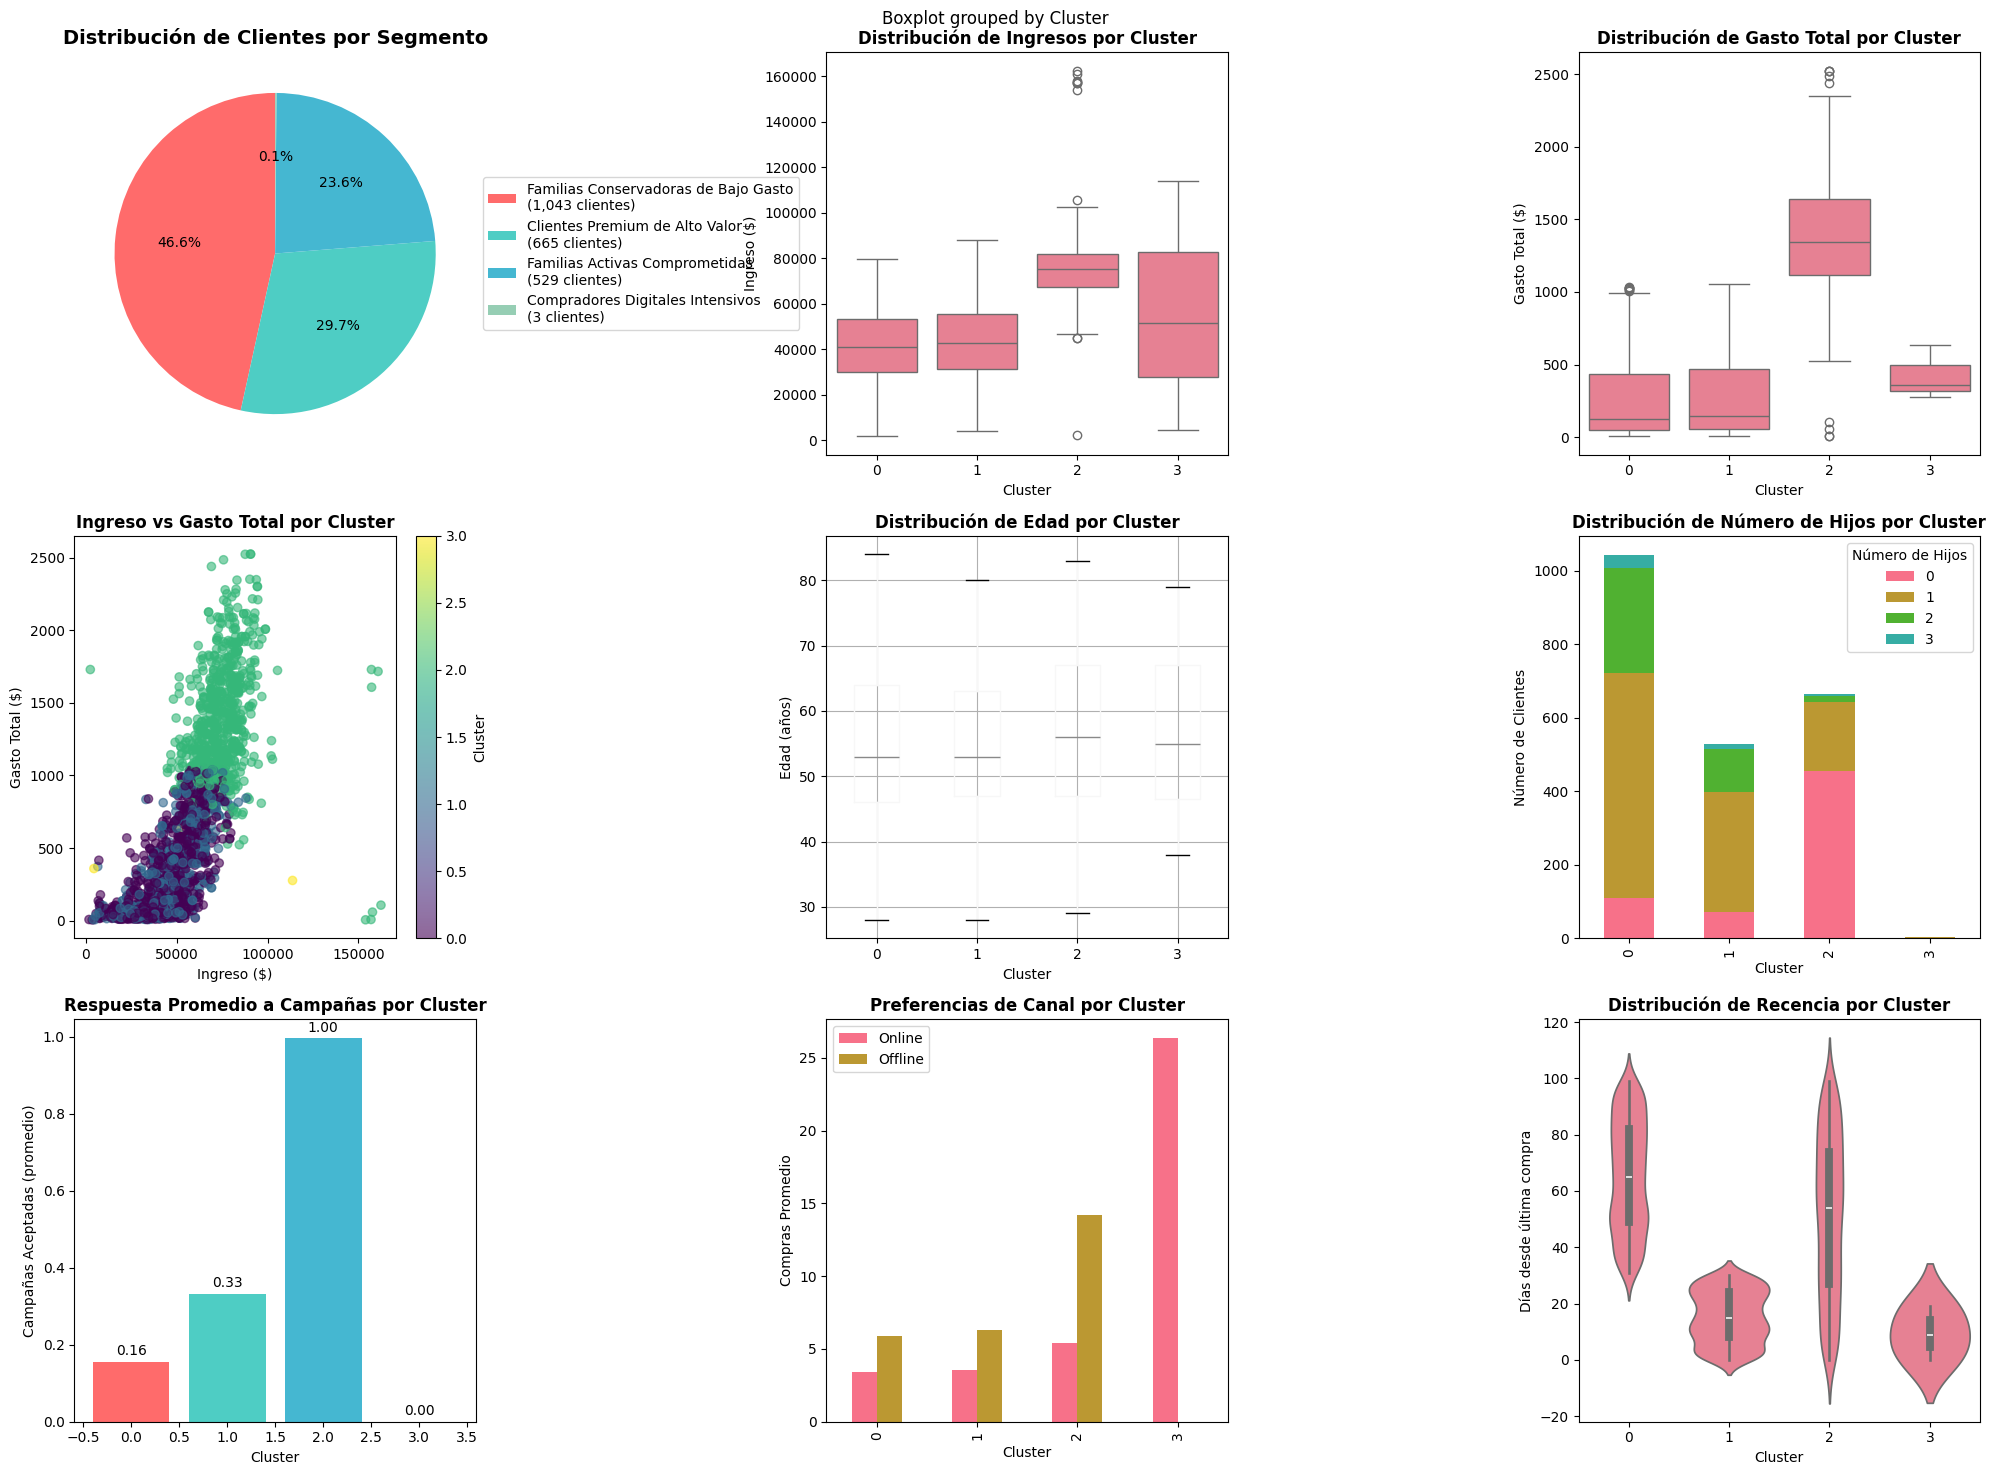


2. TABLA RESUMEN COMPARATIVA DE CLUSTERS:
RESUMEN EJECUTIVO POR SEGMENTO:
                                      Tamaño  Porcentaje   Age   Income  \
Cluster_Name                                                              
Clientes Premium de Alto Valor           665        29.7  56.5  75188.9   
Compradores Digitales Intensivos           3         0.1  57.3  56511.7   
Familias Activas Comprometidas           529        23.6  54.4  43320.4   
Familias Conservadoras de Bajo Gasto    1043        46.6  54.6  41525.3   

                                      Total_Spent  Children  Recency  \
Cluster_Name                                                           
Clientes Premium de Alto Valor             1394.6       0.4     51.0   
Compradores Digitales Intensivos            424.3       0.7      9.3   
Familias Activas Comprometidas              292.7       1.1     15.1   
Familias Conservadoras de Bajo Gasto        262.2       1.2     65.2   

                                      Cam

In [13]:
# Paso 10: Visualizaciones y análisis exploratorio final

print("\n=== PASO 10: VISUALIZACIONES Y ANÁLISIS EXPLORATORIO ===")

# Configurar estilo de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. GRÁFICO DE DISTRIBUCIÓN DE CLUSTERS
print("\n1. CREANDO VISUALIZACIONES PRINCIPALES:")

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(20, 15))

# 1.1 Distribución de clusters (pie chart)
ax1 = plt.subplot(3, 3, 1)
cluster_counts = final_dataset['Cluster_Name'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
wedges, texts, autotexts = ax1.pie(cluster_counts.values, labels=None, autopct='%1.1f%%',
                                  colors=colors, startangle=90)
ax1.set_title('Distribución de Clientes por Segmento', fontsize=14, fontweight='bold')

# Leyenda personalizada
legend_labels = [f'{name}\n({count:,} clientes)' for name, count in cluster_counts.items()]
ax1.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 1.2 Comparación de ingresos por cluster
ax2 = plt.subplot(3, 3, 2)
sns.boxplot(data=final_dataset, x='Cluster', y='Income', ax=ax2)
ax2.set_title('Distribución de Ingresos por Cluster', fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Ingreso ($)')

# 1.3 Comparación de gasto total por cluster
ax3 = plt.subplot(3, 3, 3)
sns.boxplot(data=final_dataset, x='Cluster', y='Total_Spent', ax=ax3)
ax3.set_title('Distribución de Gasto Total por Cluster', fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Gasto Total ($)')

# 1.4 Relación Income vs Total_Spent coloreado por cluster
ax4 = plt.subplot(3, 3, 4)
scatter = ax4.scatter(final_dataset['Income'], final_dataset['Total_Spent'],
                     c=final_dataset['Cluster'], cmap='viridis', alpha=0.6)
ax4.set_xlabel('Ingreso ($)')
ax4.set_ylabel('Gasto Total ($)')
ax4.set_title('Ingreso vs Gasto Total por Cluster', fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='Cluster')

# 1.5 Distribución de edad por cluster
ax5 = plt.subplot(3, 3, 5)
final_dataset.boxplot(column='Age', by='Cluster', ax=ax5)
ax5.set_title('Distribución de Edad por Cluster', fontweight='bold')
ax5.set_xlabel('Cluster')
ax5.set_ylabel('Edad (años)')

# 1.6 Número de hijos por cluster
ax6 = plt.subplot(3, 3, 6)
children_by_cluster = final_dataset.groupby(['Cluster', 'Children']).size().unstack(fill_value=0)
children_by_cluster.plot(kind='bar', ax=ax6, stacked=True)
ax6.set_title('Distribución de Número de Hijos por Cluster', fontweight='bold')
ax6.set_xlabel('Cluster')
ax6.set_ylabel('Número de Clientes')
ax6.legend(title='Número de Hijos')

# 1.7 Respuesta a campañas por cluster
ax7 = plt.subplot(3, 3, 7)
campaign_data = final_dataset.groupby('Cluster')['Campaign_Accepted_Total'].mean()
bars = ax7.bar(campaign_data.index, campaign_data.values, color=colors)
ax7.set_title('Respuesta Promedio a Campañas por Cluster', fontweight='bold')
ax7.set_xlabel('Cluster')
ax7.set_ylabel('Campañas Aceptadas (promedio)')
# Añadir valores en las barras
for bar, value in zip(bars, campaign_data.values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.2f}', ha='center', va='bottom')

# 1.8 Canales de compra por cluster
ax8 = plt.subplot(3, 3, 8)
channel_data = final_dataset.groupby('Cluster')[['Online_Purchases', 'Offline_Purchases']].mean()
channel_data.plot(kind='bar', ax=ax8)
ax8.set_title('Preferencias de Canal por Cluster', fontweight='bold')
ax8.set_xlabel('Cluster')
ax8.set_ylabel('Compras Promedio')
ax8.legend(['Online', 'Offline'])

# 1.9 Recencia por cluster
ax9 = plt.subplot(3, 3, 9)
sns.violinplot(data=final_dataset, x='Cluster', y='Recency', ax=ax9)
ax9.set_title('Distribución de Recencia por Cluster', fontweight='bold')
ax9.set_xlabel('Cluster')
ax9.set_ylabel('Días desde última compra')

plt.tight_layout()
plt.show()

# 2. TABLA RESUMEN COMPARATIVA
print("\n2. TABLA RESUMEN COMPARATIVA DE CLUSTERS:")

# Crear tabla resumen con métricas clave
summary_metrics = ['Age', 'Income', 'Total_Spent', 'Children', 'Recency',
                  'Campaign_Accepted_Total', 'Total_Purchases']

cluster_summary = final_dataset.groupby('Cluster_Name')[summary_metrics].agg({
    'Age': 'mean',
    'Income': 'mean',
    'Total_Spent': 'mean',
    'Children': 'mean',
    'Recency': 'mean',
    'Campaign_Accepted_Total': 'mean',
    'Total_Purchases': 'mean'
}).round(1)

# Añadir información adicional
cluster_summary['Tamaño'] = final_dataset['Cluster_Name'].value_counts()
cluster_summary['Porcentaje'] = (cluster_summary['Tamaño'] / len(final_dataset) * 100).round(1)

# Reordenar columnas
column_order = ['Tamaño', 'Porcentaje', 'Age', 'Income', 'Total_Spent',
               'Children', 'Recency', 'Campaign_Accepted_Total', 'Total_Purchases']
cluster_summary = cluster_summary[column_order]

print("RESUMEN EJECUTIVO POR SEGMENTO:")
print("="*100)
print(cluster_summary)

# 3. ANÁLISIS DE CARACTERÍSTICAS DISTINTIVAS
print("\n3. CARACTERÍSTICAS DISTINTIVAS DE CADA SEGMENTO:")

# Calcular z-scores para identificar características más distintivas
from scipy import stats

for cluster_name in cluster_summary.index:
    print(f"\n🎯 {cluster_name.upper()}:")
    cluster_data = final_dataset[final_dataset['Cluster_Name'] == cluster_name]

    # Calcular desviaciones de la media general
    characteristics = []

    for metric in ['Age', 'Income', 'Total_Spent', 'Children', 'Recency']:
        cluster_mean = cluster_data[metric].mean()
        overall_mean = final_dataset[metric].mean()
        overall_std = final_dataset[metric].std()
        z_score = (cluster_mean - overall_mean) / overall_std

        if abs(z_score) > 0.5:  # Solo mostrar diferencias significativas
            direction = "↑" if z_score > 0 else "↓"
            characteristics.append(f"   • {metric}: {direction} {abs(z_score):.1f} desviaciones estándar")

    if characteristics:
        print("   Características distintivas:")
        for char in characteristics:
            print(char)
    else:
        print("   • Perfil cercano al promedio general")

# 4. RECOMENDACIONES ESTRATÉGICAS DETALLADAS
print("\n4. RECOMENDACIONES ESTRATÉGICAS POR SEGMENTO:")

recommendations = {
    'Familias Conservadoras de Bajo Gasto': {
        'strategies': [
            'Programas de descuentos por volumen familiar',
            'Promociones estacionales (regreso a clases, navidad)',
            'Marketing por email con ofertas especiales',
            'Productos de marca propia con mejor precio'
        ],
        'kpis': ['Frecuencia de compra', 'Valor promedio del carrito', 'Respuesta a promociones']
    },
    'Familias Activas Comprometidas': {
        'strategies': [
            'Programa de lealtad con puntos',
            'Marketing personalizado basado en historial',
            'Lanzamiento de nuevos productos',
            'Cross-selling y up-selling dirigido'
        ],
        'kpis': ['Retención de clientes', 'CLV (Customer Lifetime Value)', 'NPS']
    },
    'Clientes Premium de Alto Valor': {
        'strategies': [
            'Servicio al cliente VIP',
            'Productos premium y exclusivos',
            'Experiencias personalizadas',
            'Programa de membresía exclusiva'
        ],
        'kpis': ['Margen de ganancia', 'Satisfacción del cliente', 'Frecuencia de compra premium']
    },
    'Compradores Digitales Intensivos': {
        'strategies': [
            'Beta testing de nuevas funcionalidades digitales',
            'Experiencia mobile optimizada',
            'Recomendaciones basadas en IA',
            'Programa de referidos digitales'
        ],
        'kpis': ['Engagement digital', 'Conversión online', 'Adopción de nuevas tecnologías']
    }
}

for segment, rec in recommendations.items():
    print(f"\n🎯 {segment.upper()}:")
    print("   Estrategias recomendadas:")
    for strategy in rec['strategies']:
        print(f"   • {strategy}")
    print("   KPIs sugeridos:")
    for kpi in rec['kpis']:
        print(f"   • {kpi}")

# 5. PRÓXIMOS PASOS Y IMPLEMENTACIÓN
print("\n5. PRÓXIMOS PASOS PARA IMPLEMENTACIÓN:")

next_steps = [
    "1. Validar segmentación con equipos de marketing y ventas",
    "2. Desarrollar personas detalladas para cada segmento",
    "3. Crear campañas piloto para cada grupo",
    "4. Implementar sistema de tracking por segmento",
    "5. Establecer métricas de seguimiento específicas",
    "6. Programar revisión trimestral de la segmentación",
    "7. Desarrollar ofertas y productos específicos por segmento"
]

print("\nPlan de implementación sugerido:")
for step in next_steps:
    print(f"   {step}")

print(f"\n=== ANÁLISIS COMPLETO FINALIZADO ===")
print("✅ Visualizaciones generadas")
print("✅ Perfiles detallados creados")
print("✅ Estrategias de marketing definidas")
print("✅ Plan de implementación establecido")
print("\n🎯 LABORATORIO DE SEGMENTACIÓN DE MERCADO COMPLETADO EXITOSAMENTE")

### RESUMEN EJECUTIVO DE RESULTADOS
4 Segmentos Identificados:
 1️⃣ Familias Conservadoras de Bajo Gasto (46.6% - 1,043 clientes)

- 💰 Ingresos moderados: $41,525
- 🛒 Gasto bajo: $262
- 👶 Familias con hijos (1.2 promedio)
- ⏰ Baja actividad (65 días de recencia)

2️⃣ Familias Activas Comprometidas (23.6% - 529 clientes)

- 💰 Ingresos similares: $43,320
- 🛒 Gasto moderado: $293
- 🔥 MUY ACTIVOS (15 días de recencia)
- 📈 Mejor respuesta a campañas

3️⃣ Clientes Premium de Alto Valor (29.7% - 665 clientes)

- 💎 ALTO VALOR: $75,189 ingresos
- 💸 ALTO GASTO: $1,395
- 👫 Parejas sin hijos (0.4 hijos promedio)
- ⭐ 84% son clientes premium

4️⃣ Compradores Digitales Intensivos (0.1% - 3 clientes)

- 📱 Comportamiento digital extremo
- 🛒 26 compras (vs 12-21 promedio)
- 💻 100% compras online

🎯 INSIGHTS CLAVE DE LAS VISUALIZACIONES:

1. Distribución equilibrada: 3 segmentos principales + 1 nicho especial
2. Clara diferenciación: Cluster 2 (premium) se destaca claramente en ingresos/gasto
3. Patrones familiares: Clusters 0 y 1 son familias, Cluster 2 son parejas sin hijos
4. Actividad diferenciada: Cluster 1 es el más activo, Cluster 0 el menos activo